In [2]:
using DataFrames, XLSX, CSV
using CairoMakie

In [3]:
df= XLSX.readtable("D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/02 fatigue delamination/AP5MEF104_Sim.xlsx", "Sheet1") |> DataFrame;

## Figure Stress Curves

In [4]:
# Plot the first curve with lines and markers
fig = Figure(resolution = (1200, 1200))
font=24
ax1_1 = Axis(fig[1,1],
    xlabel = L"w (mm)",
    ylabel = L"P (N)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


ax2_1 = Axis(fig[1,2],
    xlabel = L"w (mm)",
    ylabel = L"τ (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax3_1 = Axis(fig[1,3],
    xlabel = L"w (um)",
    ylabel = L"σ (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax4_1 = Axis(fig[2,1],
    xlabel = L"a (um)",
    ylabel = L"τ(MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax5_1 = Axis(fig[2,2],
    xlabel = L"a (um)",
    ylabel = L"σ (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)





Axis with 0 plots:


## Figure VCCT Curves

In [5]:
# Plot the first curve with lines and markers
fig2 = Figure(resolution = (1200, 1200))
font=24


ax1_2 = Axis(fig2[1,1],
    xlabel = L"w (mm)",
    ylabel = L"ux1-ux2  (um)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


ax2_2 = Axis(fig2[1,2],
    xlabel = L"w (mm)",
    ylabel = L"uy1-uy2 (um)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


ax3_2 = Axis(fig2[1,3],
    xlabel = L"ux1-ux2  (um)",
    ylabel = L"Fx (N)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax4_2 = Axis(fig2[2,1],
    xlabel = L"uy1-uy2  (um)",
    ylabel = L"Fy (N)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)



ax5_2 = Axis(fig2[2,2],
    xlabel = L"δy (um)",
    ylabel = L"Fy (N)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax6_2 = Axis(fig2[3,1],
    xlabel = L"w (mm)",
    ylabel = L"GI(J/m2)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax7_2 = Axis(fig2[3,2],
    xlabel = L"w (mm)",
    ylabel = L"GII(J/m2)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


Axis with 0 plots:


## Functions

In [6]:
function filter_range2(df::DataFrame, column::String, low, high)
    return filter(row -> low ≤ row[column] ≤ high, df)
end

filter_range2 (generic function with 1 method)

In [7]:


function filter_range(df::DataFrame, column::String, a0)
    return filter(row -> row[column] ==a0, df)
end

filter_range (generic function with 1 method)

In [8]:
function plotBendingCurves(ax1,ax2,ax3,ax4,ax5,df)
    Makie.scatter!(ax1,abs.(df[!,:dy]),abs.(df[!,:P]))
    Makie.lines!(ax1,abs.(df[!,:dy]),abs.(df[!,:P]))

    Makie.scatter!(ax2,abs.(df[!,:dy]),abs.(df[!,:τ_front]))
    Makie.lines!(ax2,abs.(df[!,:dy]),abs.(df[!,:τ_front]))

    Makie.scatter!(ax3,abs.(df[!,:dy]),abs.(df[!,:σ_front]))
    Makie.lines!(ax3,abs.(df[!,:dy]),abs.(df[!,:σ_front]))


    Makie.scatter!(ax4,abs.(df[!,:PrecrackRechts]),abs.(df[!,:τ_front]))
    Makie.lines!(ax4,abs.(df[!,:PrecrackRechts]),abs.(df[!,:τ_front]))


    Makie.scatter!(ax5,abs.(df[!,:PrecrackRechts]),abs.(df[!,:σ_front]))
    Makie.lines!(ax5,abs.(df[!,:PrecrackRechts]),abs.(df[!,:σ_front]))


end


plotBendingCurves (generic function with 1 method)

In [9]:


function plotProperties2!(fig, df_log,ax1,ax2,ax3)
        

        epsilon=df_log[!," Strain Rate[%/min]"]
        E=df_log[!,"E[GPa] "]
        Makie.scatter!(ax1,epsilon,E)
        Makie.lines!(ax1,epsilon,E)

        Makie.scatter!(ax2,df_log[!," Strain Rate[%/min]"],df_log[!,"sigmaMax"])
        Makie.lines!(ax2,df_log[!," Strain Rate[%/min]"],df_log[!,"sigmaMax"])


        Makie.scatter!(ax3,df_log[!," Strain Rate[%/min]"],df_log[!,"sigma0_25% "])
        Makie.lines!(ax3,df_log[!," Strain Rate[%/min]"],df_log[!,"sigma0_25% "])
        
        
        return fig

end

plotProperties2! (generic function with 1 method)

In [10]:
function plotVCCTCurves(ax1,ax2,ax3,ax4,ax5,ax6,ax7,df)
    Makie.scatter!(ax1,abs.(df[!,:dy]),abs.(df[!,:δ_x]))
    Makie.lines!(ax1,abs.(df[!,:dy]),abs.(df[!,:δ_x]))

    Makie.scatter!(ax2,abs.(df[!,:dy]),abs.(df[!,:δ_y]))
    Makie.lines!(ax2,abs.(df[!,:dy]),abs.(df[!,:δ_y]))

    Makie.scatter!(ax3,abs.(df[!,:δ_x]),abs.(df[!,:Fx_Front]))
    Makie.lines!(ax3,abs.(df[!,:δ_x]),abs.(df[!,:Fx_Front]))


    Makie.scatter!(ax4,abs.(df[!,:δ_y]),abs.(df[!,:Fy_Front]))
    Makie.lines!(ax4,abs.(df[!,:δ_y]),abs.(df[!,:Fy_Front]))

    Makie.scatter!(ax5,abs.(df[!,:delta_y]),abs.(df[!,:Fy_Front]))
    Makie.lines!(ax5,abs.(df[!,:delta_y]),abs.(df[!,:Fy_Front]))

    Makie.scatter!(ax6,abs.(df[!,:dy]),abs.(df[!,:GI]))
    Makie.lines!(ax6,abs.(df[!,:dy]),abs.(df[!,:GI]))

    Makie.scatter!(ax7,abs.(df[!,:dy]),abs.(df[!,:GII]))
    Makie.lines!(ax7,abs.(df[!,:dy]),abs.(df[!,:GII]))
end

plotVCCTCurves (generic function with 1 method)

In [11]:
df

Row,N,SiAbstandRechts,SiRechts,dy,PrecrackLinks,PrecrackRechts,S_AlleMax,S_StahlMax,S_KlebebandBottomMax,S_KlebebandBottomMean,u_AlleMax,u_KlebebandBottomMax,u_KlebebandBottomMean,Sy_ParyleneMin,Sy_ParyleneMax,Sx_ParyleneMin,Sx_ParyleneMax,Sy_SiMin,Sy_SiMax,Sx_SiMin,Sx_SiMax,Sy_SiPaMin,Sy_SiPaMax,Sx_SiPaMin,Sx_SiPaMax,Fx_Front,Fy_Front,Fx_SiPa,Fy_SiPa,P,dx_Parylene,dx_Si,dy_Parylene,dy_Si,deltay_Parylene,deltay_Si,S_AlleMax_2
,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any
1,1,21.25,21.25,1.5,0.1,0.1,196.728,196.728,72.6363,2.70484,0.0518419,0.0363182,0.00135264,-55.6866,26.5994,-14.7379,8.56882,-16.4123,26.7332,-23.6093,42.2756,-55.6866,26.7332,-23.6093,42.2756,-0.00102967,0.0911208,17.3696,-0.0369061,2.29258,-8.60613e-6,-8.60391e-6,0.00128825,0.00128843,0.0012867,0.0012867,54.434
2,2,21.25,21.25,2,0.1,0.1,262.577,262.577,96.6634,3.62883,0.0684261,0.0483317,0.00181471,-73.649,35.0429,-19.1766,11.0314,-21.8092,35.6293,-31.1484,56.2212,-73.649,35.6293,-31.1484,56.2212,-0.00561872,0.119991,23.2097,-0.0485961,3.06553,-1.14809e-5,-1.1481e-5,0.00171767,0.0017179,0.00171559,0.00171559,71.8474
3,3,21.25,21.25,2.5,0.1,0.1,328.51,328.51,120.665,4.55683,0.0849789,0.0603327,0.0022788,-91.6242,43.5028,-23.5459,13.5221,-27.2107,44.5378,-38.6648,70.1755,-91.6242,44.5378,-38.6648,70.1755,-0.0102036,0.148867,29.0668,-0.0602534,3.84188,-1.43717e-5,-1.4374e-5,0.00214692,0.0021472,0.00214431,0.00214431,89.2279
4,4,21.25,21.25,3,0.1,0.1,394.563,394.563,144.675,5.48852,0.101881,0.0723374,0.00274472,-109.983,52.2095,-27.9094,16.0918,-32.6415,53.4647,-46.2277,84.1712,-109.983,53.4647,-46.2277,84.1712,-0.0147066,0.177907,34.9412,-0.0715412,4.62185,-1.72689e-5,-1.72733e-5,0.00257614,0.00257648,0.002573,0.002573,106.975
5,5,21.25,21.25,3.5,0.1,0.1,460.713,460.713,168.696,6.42344,0.120575,0.0843479,0.00321226,-130.259,61.9104,-32.188,18.9059,-38.1648,62.4083,-54.0193,98.5304,-130.259,62.4083,-54.0193,98.5304,-0.0200516,0.210288,40.839,-0.0838935,5.40671,-2.01919e-5,-2.01992e-5,0.0030051,0.00300548,0.00300141,0.00300141,126.604
6,6,21.25,21.25,4,0.1,0.1,526.988,526.988,192.747,7.36091,0.13894,0.0963736,0.00368108,-150.161,70.8526,-36.5565,21.7393,-43.6868,71.3719,-61.8095,113.442,-150.161,71.3719,-61.8095,113.442,-0.0249248,0.249345,46.7526,-0.105027,6.19481,-2.31166e-5,-2.31272e-5,0.0034341,0.00343454,0.00342988,0.00342988,145.887
7,7,21.25,21.25,1.5,0.3,0.3,196.635,196.635,72.689,2.74906,0.0531092,0.0363445,0.00137475,-57.0545,30.4115,-15.1093,9.67799,-16.8738,26.7248,-24.3073,40.858,-57.0545,30.4115,-24.3073,40.858,0.00172448,0.10411,17.3544,-0.0413418,2.29119,-8.59346e-6,-8.58833e-6,0.00129287,0.00129307,0.00128744,0.00128744,55.7646
8,8,21.25,21.25,2,0.3,0.3,262.449,262.449,96.7291,3.68806,0.0701317,0.0483645,0.00184433,-75.4952,40.2242,-19.6729,12.546,-22.4312,35.6173,-32.0793,54.2473,-75.4952,40.2242,-32.0793,54.2473,-0.00258051,0.137635,23.1899,-0.0546204,3.06369,-1.14651e-5,-1.14619e-5,0.00172382,0.00172409,0.00171657,0.00171657,73.6383
9,9,21.25,21.25,2.5,0.3,0.3,328.349,328.349,120.744,4.63113,0.0871195,0.060372,0.00231594,-93.9466,50.0547,-24.1642,15.4482,-27.9922,44.5224,-39.8247,67.6618,-93.9466,50.0547,-39.8247,67.6618,-0.00691567,0.171155,29.0424,-0.0678585,3.83958,-1.43522e-5,-1.43507e-5,0.00215461,0.00215494,0.00214552,0.00214552,91.4755


In [12]:
width=2*1e-3 #m
delta_crack=1e-6 #m 
s_crack=width*delta_crack #m2

2.0e-9

In [13]:
df[!,:GI]=(df[!,:Fy_Front].*(df[!,:dy_Parylene]-df[!,:dy_Si])*-1)/(2*s_crack)
df[!,:GII]=(df[!,:Fx_Front].*(df[!,:dx_Parylene]-df[!,:dx_Si])*-1)/(2*s_crack)
df[!,:δ_x]=(-df[!,:dx_Parylene]+df[!,:dx_Si])
df[!,:δ_y]=(-df[!,:dy_Parylene]+df[!,:dy_Si])
df[!,:τ_front]=df[!,:Fx_Front]*1e-6./s_crack #MPa
df[!,:σ_front]=df[!,:Fy_Front]*1e-6./s_crack #MPa
df[!,:delta_y]=(-df[!,:deltay_Parylene]+df[!,:deltay_Si]) ## Aperture in um


30-element Vector{Float64}:
 -1.1641532009221134e-10
 -2.3283063996758224e-10
 -4.656612899098245e-10
 -2.328306497254018e-10
 -2.3283065015908266e-10
 -4.656612799351645e-10
  0.0
  0.0
  0.0
  0.0
  ⋮
  2.3283064018442268e-10
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0

In [14]:
df_sim=df

Row,N,SiAbstandRechts,SiRechts,dy,PrecrackLinks,PrecrackRechts,S_AlleMax,S_StahlMax,S_KlebebandBottomMax,S_KlebebandBottomMean,u_AlleMax,u_KlebebandBottomMax,u_KlebebandBottomMean,Sy_ParyleneMin,Sy_ParyleneMax,Sx_ParyleneMin,Sx_ParyleneMax,Sy_SiMin,Sy_SiMax,Sx_SiMin,Sx_SiMax,Sy_SiPaMin,Sy_SiPaMax,Sx_SiPaMin,Sx_SiPaMax,Fx_Front,Fy_Front,Fx_SiPa,Fy_SiPa,P,dx_Parylene,dx_Si,dy_Parylene,dy_Si,deltay_Parylene,deltay_Si,S_AlleMax_2,GI,GII,δ_x,δ_y,τ_front,σ_front,delta_y
,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1,21.25,21.25,1.5,0.1,0.1,196.728,196.728,72.6363,2.70484,0.0518419,0.0363182,0.00135264,-55.6866,26.5994,-14.7379,8.56882,-16.4123,26.7332,-23.6093,42.2756,-55.6866,26.7332,-23.6093,42.2756,-0.00102967,0.0911208,17.3696,-0.0369061,2.29258,-8.60613e-6,-8.60391e-6,0.00128825,0.00128843,0.0012867,0.0012867,54.434,4.00977,-0.000570318,2.21553e-9,1.7602e-7,-0.514837,45.5604,-1.16415e-10
2,2,21.25,21.25,2,0.1,0.1,262.577,262.577,96.6634,3.62883,0.0684261,0.0483317,0.00181471,-73.649,35.0429,-19.1766,11.0314,-21.8092,35.6293,-31.1484,56.2212,-73.649,35.6293,-31.1484,56.2212,-0.00561872,0.119991,23.2097,-0.0485961,3.06553,-1.14809e-5,-1.1481e-5,0.00171767,0.0017179,0.00171559,0.00171559,71.8474,6.93199,0.000126477,-9.004e-11,2.31084e-7,-2.80936,59.9953,-2.32831e-10
3,3,21.25,21.25,2.5,0.1,0.1,328.51,328.51,120.665,4.55683,0.0849789,0.0603327,0.0022788,-91.6242,43.5028,-23.5459,13.5221,-27.2107,44.5378,-38.6648,70.1755,-91.6242,44.5378,-38.6648,70.1755,-0.0102036,0.148867,29.0668,-0.0602534,3.84188,-1.43717e-5,-1.4374e-5,0.00214692,0.0021472,0.00214431,0.00214431,89.2279,10.6495,0.00589288,-2.31012e-9,2.86149e-7,-5.10181,74.4333,-4.65661e-10
4,4,21.25,21.25,3,0.1,0.1,394.563,394.563,144.675,5.48852,0.101881,0.0723374,0.00274472,-109.983,52.2095,-27.9094,16.0918,-32.6415,53.4647,-46.2277,84.1712,-109.983,53.4647,-46.2277,84.1712,-0.0147066,0.177907,34.9412,-0.0715412,4.62185,-1.72689e-5,-1.72733e-5,0.00257614,0.00257648,0.002573,0.002573,106.975,15.1295,0.0162647,-4.42378e-9,3.40166e-7,-7.35329,88.9535,-2.32831e-10
5,5,21.25,21.25,3.5,0.1,0.1,460.713,460.713,168.696,6.42344,0.120575,0.0843479,0.00321226,-130.259,61.9104,-32.188,18.9059,-38.1648,62.4083,-54.0193,98.5304,-130.259,62.4083,-54.0193,98.5304,-0.0200516,0.210288,40.839,-0.0838935,5.40671,-2.01919e-5,-2.01992e-5,0.0030051,0.00300548,0.00300141,0.00300141,126.604,20.319,0.0366286,-7.30688e-9,3.86499e-7,-10.0258,105.144,-2.32831e-10
6,6,21.25,21.25,4,0.1,0.1,526.988,526.988,192.747,7.36091,0.13894,0.0963736,0.00368108,-150.161,70.8526,-36.5565,21.7393,-43.6868,71.3719,-61.8095,113.442,-150.161,71.3719,-61.8095,113.442,-0.0249248,0.249345,46.7526,-0.105027,6.19481,-2.31166e-5,-2.31272e-5,0.0034341,0.00343454,0.00342988,0.00342988,145.887,26.9085,0.0656041,-1.05283e-8,4.31668e-7,-12.4624,124.672,-4.65661e-10
7,7,21.25,21.25,1.5,0.3,0.3,196.635,196.635,72.689,2.74906,0.0531092,0.0363445,0.00137475,-57.0545,30.4115,-15.1093,9.67799,-16.8738,26.7248,-24.3073,40.858,-57.0545,30.4115,-24.3073,40.858,0.00172448,0.10411,17.3544,-0.0413418,2.29119,-8.59346e-6,-8.58833e-6,0.00129287,0.00129307,0.00128744,0.00128744,55.7646,5.23586,0.00221184,5.13046e-9,2.01166e-7,0.862238,52.0552,0.0
8,8,21.25,21.25,2,0.3,0.3,262.449,262.449,96.7291,3.68806,0.0701317,0.0483645,0.00184433,-75.4952,40.2242,-19.6729,12.546,-22.4312,35.6173,-32.0793,54.2473,-75.4952,40.2242,-32.0793,54.2473,-0.00258051,0.137635,23.1899,-0.0546204,3.06369,-1.14651e-5,-1.14619e-5,0.00172382,0.00172409,0.00171657,0.00171657,73.6383,9.12099,-0.00210229,3.25872e-9,2.65078e-7,-1.29025,68.8175,0.0
9,9,21.25,21.25,2.5,0.3,0.3,328.349,328.349,120.744,4.63113,0.0871195,0.060372,0.00231594,-93.9466,50.0547,-24.1642,15.4482,-27.9922,44.5224,-39.8247,67.6618,-93.9466,50.0547,-39.8247,67.6618,-0.00691567,0.171155,29.0424,-0.0678585,3.83958,-1.43522e-5,-1.43507e-5,0.00215461,0.0

In [15]:
using Interpolations

In [16]:
function InterpolateG(s,a)
    #a PrecrackLinks
    #s amplitude nominal
    
    df_dy=Float64.(filter_range(df_sim,"dy",s))
    precrack=df_dy."PrecrackLinks"
    G=df_dy."GI"

    itp = interpolate((precrack,), G, Gridded(Linear()))
    val = itp(a)
    return val
end


InterpolateG (generic function with 1 method)

In [17]:
InterpolateG(4,0.1)

26.90854357669264

## Pre crack 10 50 100 200 300 500

In [18]:

for i in [ 0.1, 0.3, 0.5, 0.75, 1]

    df_filter=Float64.(filter_range(df,"PrecrackLinks",i))
    plotBendingCurves(ax1_1,ax2_1,ax3_1,ax4_1,ax5_1,df_filter)
    plotVCCTCurves(ax1_2,ax2_2,ax3_2,ax4_2,ax5_2,ax6_2,ax7_2,df_filter)
end


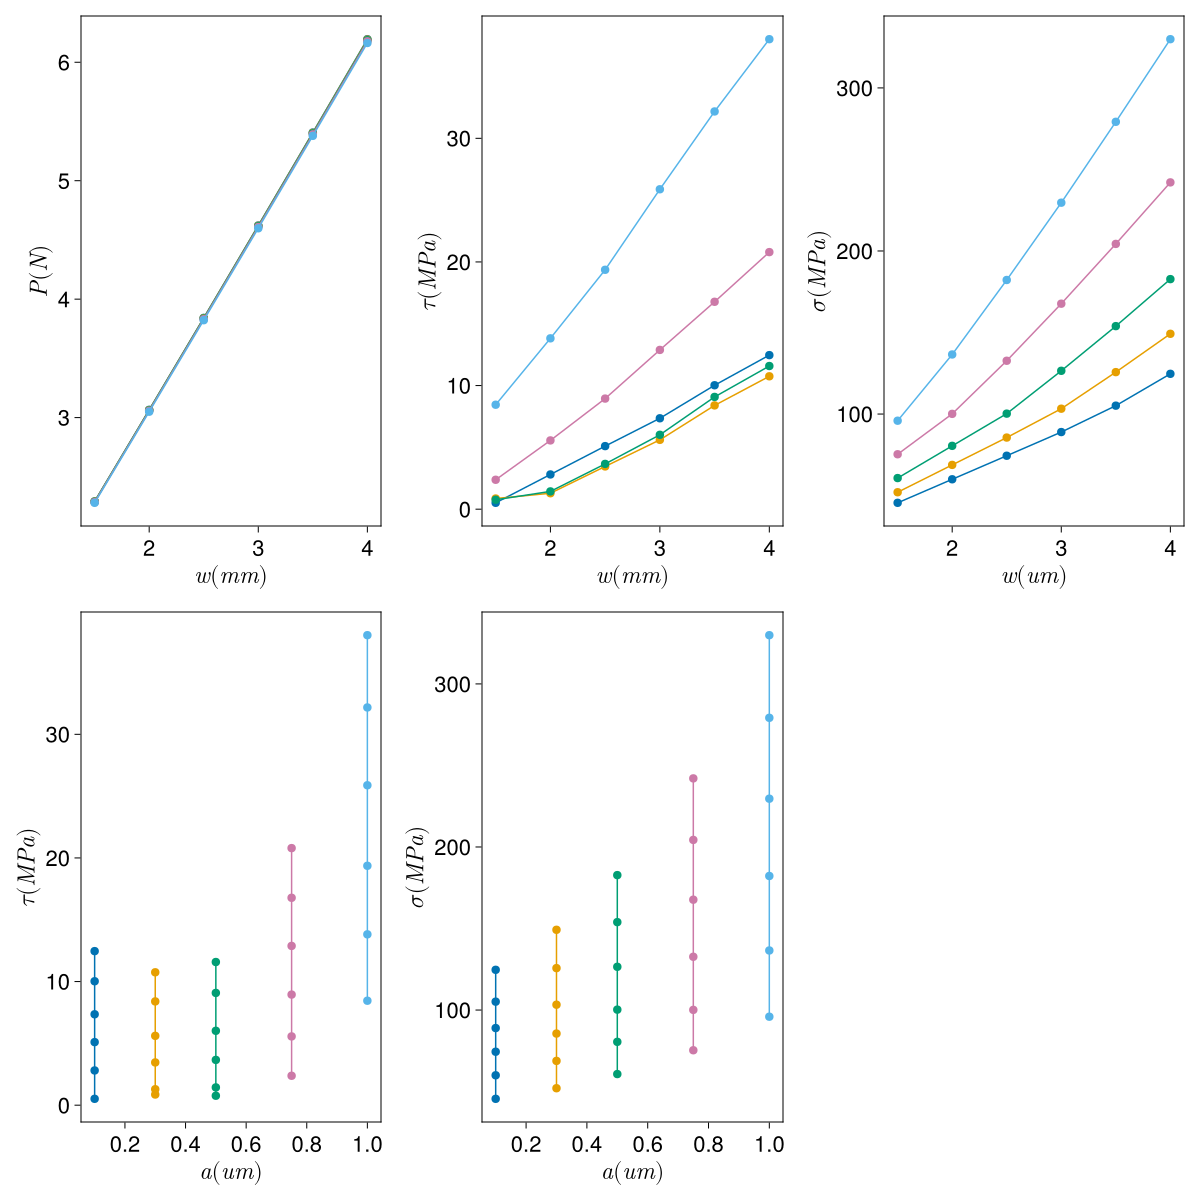

In [19]:
fig

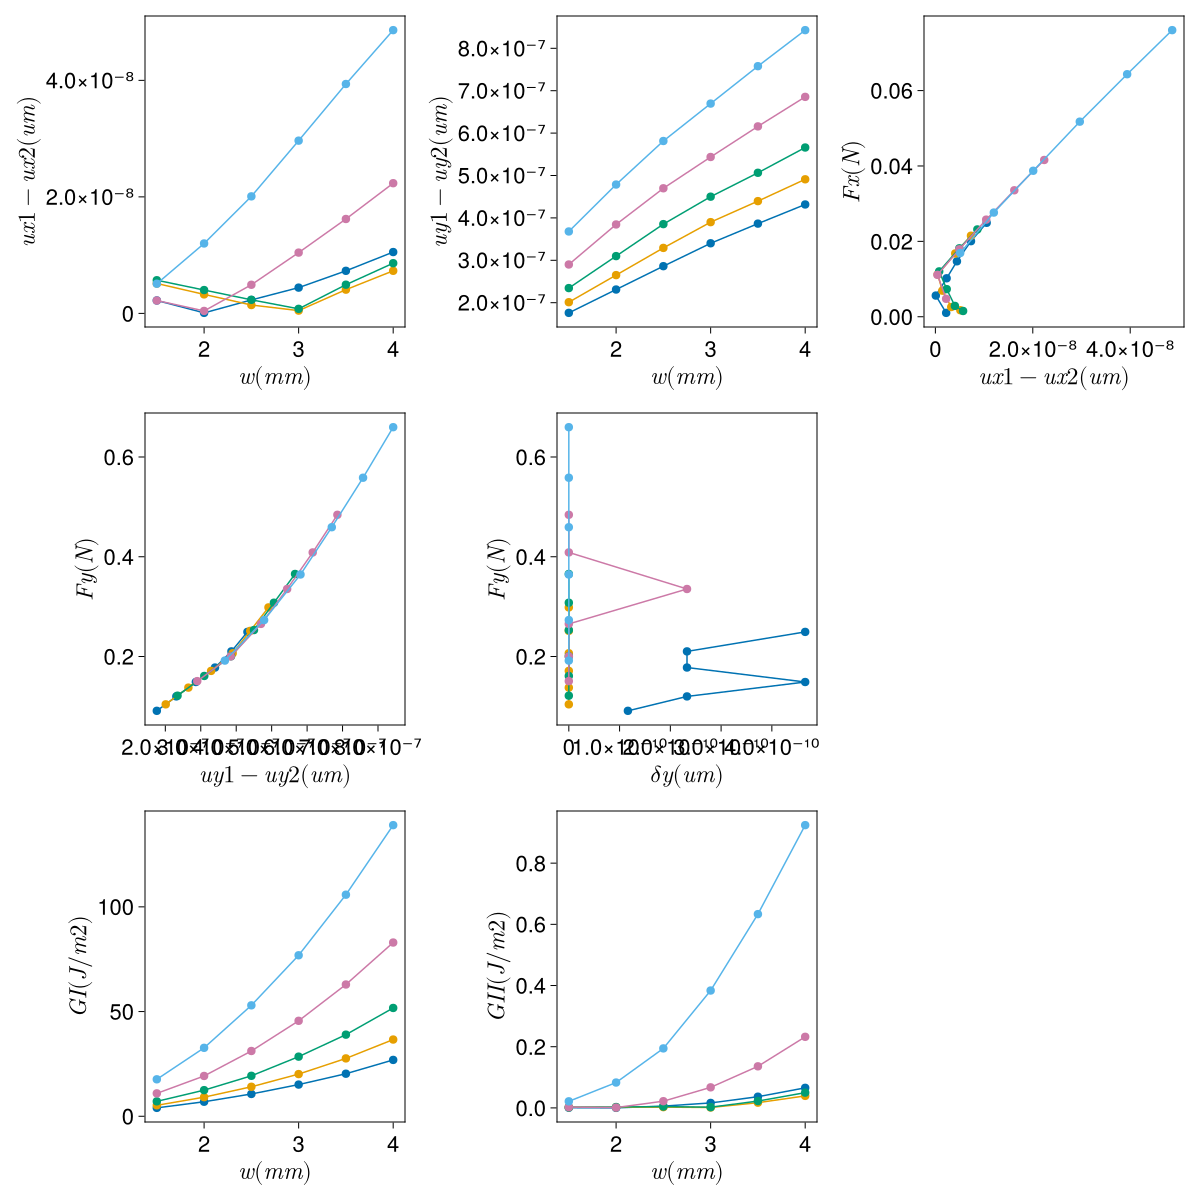

In [20]:
fig2

## Experimental Fatigue AP5MEF1-04 Raum

In [21]:
function importTest(path)

    #file = XLSX.readxlsx(path)
    df=CSV.read(path,DataFrame) 
    
    for col in names(df)
        if eltype(df[!, col]) <: AbstractString
           
                df[!, col] = parse.(Float64, replace.(df[!, col], "," => "."))
                # skip columns that cannot be converted
            
        end#
    
    end

    return df
end


importTest (generic function with 1 method)

In [22]:
df_exp=df= XLSX.readtable("D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/02 fatigue delamination/AP5MEF104_Fatigue.xlsx", "Sheet1") |> DataFrame

Row,Name,Sample,Temperature,a,s,d,f,a0Links,a0Mitte,a0Rechts,aiLinks,aiMitte,aiRechts,afLinks,afMitte,afRechts,Delta,DeltaAccu,N,dadN,Naccu,Obs
,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any
1,260217-1_A,A,Raum,0.8,1,25,1.2,108.2,17.91,23.1,108.2,17.91,23.1,87.98,21.64,32.64,3.73,3.73,1000,3.73,5000,"Corrected to 1000 ""effective cycle"""
2,260217-1_B,B,Raum,0.8,1,25,1.2,98.21,16.42,25.7,98.21,16.42,25.7,90.01,24.7,31.77,8.28,8.28,1000,8.28,5000,missing
3,260217-2_A,A,Raum,0.8,1,25,1.2,68.87,9.84,16.32,68.87,9.84,16.32,67.46,15.93,missing,6.09,6.09,1000,6.09,5000,missing
4,260217-2_B,B,Raum,0.8,1,25,1.2,105.3,11.07,25.39,105.3,11.07,25.39,102.59,17.01,27.32,5.94,5.94,1000,5.94,5000,missing
5,260217-1_A,A,Raum,0.8,1,25,1.2,108.2,17.91,23.1,87.98,21.64,32.64,88.44,26.84,41.91,5.2,8.93,10000,0.52,15000,missing
6,260217-1_B,B,Raum,0.8,1,25,1.2,98.21,16.42,25.7,90.01,24.7,31.77,92.77,28.37,35.44,3.67,11.95,10000,0.367,15000,"Corrected initial 23,17"
7,260217-2_A,A,Raum,0.8,1,25,1.2,68.87,9.84,16.32,67.46,15.93,missing,31.67,20.39,16.507,4.46,10.55,10000,0.446,15000,missing
8,260217-2_B,B,Raum,0.8,1,25,1.2,105.3,11.07,25.39,102.59,17.01,27.32,85.75,20.46,76.7,3.45,9.39,10000,0.345,15000,missing
9,260217-1_A,A,Raum,1.3,1.5,25,1.2,108.2,17.91,23.1,88.44,26.84,41.91,97.54,28.75,56.38,1.91,10.84,1000,1.91,35000,"Corrected to 5000 ""effective cycle"""


In [23]:
for i in 1:4
    delete!(df_exp,1)
end

In [24]:
df_exp[!,:aLinks]=150 .+ df_exp[!,:afLinks]
df_exp[!,:aRechts]=150 .+ df_exp[!,:afRechts]
df_exp[!,:aMitte]=150 .+ df_exp[!,:afMitte]

12-element Vector{Float64}:
 176.84
 178.37
 170.39
 170.46
 178.75
 176.51
 175.52
 173.72
 180.16
 179.86
 183.35
 206.603

In [25]:
df_exp[!,:delta_aLinksAccu]= df_exp[!,:afLinks] -df_exp[!,:a0Links]
df_exp[!,:delta_aRechtsAccu]= df_exp[!,:afRechts] -df_exp[!,:a0Rechts]
df_exp[!,:delta_aMitteAccu]= df_exp[!,:afMitte] -df_exp[!,:a0Mitte]

12-element Vector{Float64}:
  8.93
 11.95
 10.55
  9.39
 10.84
 10.09
 15.68
 12.649999999999999
 12.25
 13.439999999999998
 23.51
 45.533

In [26]:
df_exp[!,:delta_aLinks]= df_exp[!,:afLinks] -df_exp[!,:aiLinks]
df_exp[!,:delta_aRechts]= df_exp[!,:afRechts] -df_exp[!,:aiRechts]
df_exp[!,:delta_aMitte]= df_exp[!,:afMitte] -df_exp[!,:aiMitte]

df_exp[!,:dadNLinks]= df_exp[!,:delta_aLinks]./df_exp[!,:N]
df_exp[!,:dadNRechts]= df_exp[!,:delta_aRechts]./df_exp[!,:N]
df_exp[!,:dadNMitte]= df_exp[!,:delta_aMitte]./df_exp[!,:N]

12-element Vector{Float64}:
 0.00052
 0.0003670000000000002
 0.0004460000000000001
 0.00034499999999999993
 0.0019100000000000002
 0.0033399999999999997
 0.005129999999999999
 0.003259999999999998
 0.0028200000000000005
 0.006699999999999996
 0.015660000000000004
 0.006326000000000008

In [27]:
df_exp[!,:dadNMitte]

12-element Vector{Float64}:
 0.00052
 0.0003670000000000002
 0.0004460000000000001
 0.00034499999999999993
 0.0019100000000000002
 0.0033399999999999997
 0.005129999999999999
 0.003259999999999998
 0.0028200000000000005
 0.006699999999999996
 0.015660000000000004
 0.006326000000000008

In [28]:
GI_exp=Float64[]
df_exp[!,:GI]=df_exp[!,:delta_aLinks] # create a column

12-element Vector{Float64}:
   0.45999999999999375
   2.759999999999991
 -35.78999999999999
 -16.840000000000003
   9.100000000000009
  -2.8799999999999955
  38.75
  11.099999999999994
  -9.190000000000012
   4.030000000000001
   3.8100000000000023
  -0.8599999999999994

In [29]:
df_exp

Row,Name,Sample,Temperature,a,s,d,f,a0Links,a0Mitte,a0Rechts,aiLinks,aiMitte,aiRechts,afLinks,afMitte,afRechts,Delta,DeltaAccu,N,dadN,Naccu,Obs,aLinks,aRechts,aMitte,delta_aLinksAccu,delta_aRechtsAccu,delta_aMitteAccu,delta_aLinks,delta_aRechts,delta_aMitte,dadNLinks,dadNRechts,dadNMitte,GI
,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64?,Float64,Float64,Float64?,Float64,Float64
1,260217-1_A,A,Raum,0.8,1,25,1.2,108.2,17.91,23.1,87.98,21.64,32.64,88.44,26.84,41.91,5.2,8.93,10000,0.52,15000,missing,238.44,191.91,176.84,-19.76,18.81,8.93,0.46,9.27,5.2,4.6e-5,0.000927,0.00052,0.46
2,260217-1_B,B,Raum,0.8,1,25,1.2,98.21,16.42,25.7,90.01,24.7,31.77,92.77,28.37,35.44,3.67,11.95,10000,0.367,15000,"Corrected initial 23,17",242.77,185.44,178.37,-5.44,9.74,11.95,2.76,3.67,3.67,0.000276,0.000367,0.000367,2.76
3,260217-2_A,A,Raum,0.8,1,25,1.2,68.87,9.84,16.32,67.46,15.93,missing,31.67,20.39,16.507,4.46,10.55,10000,0.446,15000,missing,181.67,166.507,170.39,-37.2,0.187,10.55,-35.79,missing,4.46,-0.003579,missing,0.000446,-35.79
4,260217-2_B,B,Raum,0.8,1,25,1.2,105.3,11.07,25.39,102.59,17.01,27.32,85.75,20.46,76.7,3.45,9.39,10000,0.345,15000,missing,235.75,226.7,170.46,-19.55,51.31,9.39,-16.84,49.38,3.45,-0.001684,0.004938,0.000345,-16.84
5,260217-1_A,A,Raum,1.3,1.5,25,1.2,108.2,17.91,23.1,88.44,26.84,41.91,97.54,28.75,56.38,1.91,10.84,1000,1.91,35000,"Corrected to 5000 ""effective cycle""",247.54,206.38,178.75,-10.66,33.28,10.84,9.1,14.47,1.91,0.0091,0.01447,0.00191,9.1
6,260217-1_B,B,Raum,1.3,1.5,25,1.2,98.21,16.42,25.7,92.77,23.17,35.44,89.89,26.51,45.52,3.34,10.09,1000,3.34,35000,missing,239.89,195.52,176.51,-8.32,19.82,10.09,-2.88,10.08,3.34,-0.00288,0.01008,0.00334,-2.88
7,260217-2_A,A,Raum,1.3,1.5,25,1.2,68.87,9.84,16.32,31.67,20.39,16.507,70.42,25.52,34.43,5.13,15.68,1000,5.13,35000,missing,220.42,184.43,175.52,1.55,18.11,15.68,38.75,17.923,5.13,0.03875,0.017923,0.00513,38.75
8,260217-2_B,B,Raum,1.3,1.5,25,1.2,105.3,11.07,25.39,85.75,20.46,76.7,96.85,23.72,50.67,3.26,12.65,1000,3.26,35000,missing,246.85,200.67,173.72,-8.45,25.28,12.65,11.1,-26.03,3.26,0.0111,-0.02603,0.00326,11.1
9,260217-1_A,A,Raum,1.8,2,25,1.2,108.2,17.91,23.1,97.54,28.75,56.38,88.35,30.16,57.2,1.41,12.25,500,2.82,55000,missing,238.35,207.2,180.16,-19.85,34.1,12.25,-9.19,0.82,1.41,-0.01838,0.00164,0.00282,-9.19


In [30]:
n=1
for i in df_exp."aMitte"
    
    df_exp[n,:GI]=InterpolateG(2*df_exp."s"[n],i/1000)
    n=n+1
end

In [31]:
df_exp

Row,Name,Sample,Temperature,a,s,d,f,a0Links,a0Mitte,a0Rechts,aiLinks,aiMitte,aiRechts,afLinks,afMitte,afRechts,Delta,DeltaAccu,N,dadN,Naccu,Obs,aLinks,aRechts,aMitte,delta_aLinksAccu,delta_aRechtsAccu,delta_aMitteAccu,delta_aLinks,delta_aRechts,delta_aMitte,dadNLinks,dadNRechts,dadNMitte,GI
,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64?,Float64,Float64,Float64?,Float64,Float64
1,260217-1_A,A,Raum,0.8,1,25,1.2,108.2,17.91,23.1,87.98,21.64,32.64,88.44,26.84,41.91,5.2,8.93,10000,0.52,15000,missing,238.44,191.91,176.84,-19.76,18.81,8.93,7.773,9.27,5.2,4.6e-5,0.000927,0.00052,7.773
2,260217-1_B,B,Raum,0.8,1,25,1.2,98.21,16.42,25.7,90.01,24.7,31.77,92.77,28.37,35.44,3.67,11.95,10000,0.367,15000,"Corrected initial 23,17",242.77,185.44,178.37,-5.44,9.74,11.95,7.78975,3.67,3.67,0.000276,0.000367,0.000367,7.78975
3,260217-2_A,A,Raum,0.8,1,25,1.2,68.87,9.84,16.32,67.46,15.93,missing,31.67,20.39,16.507,4.46,10.55,10000,0.446,15000,missing,181.67,166.507,170.39,-37.2,0.187,10.55,7.70241,missing,4.46,-0.003579,missing,0.000446,7.70241
4,260217-2_B,B,Raum,0.8,1,25,1.2,105.3,11.07,25.39,102.59,17.01,27.32,85.75,20.46,76.7,3.45,9.39,10000,0.345,15000,missing,235.75,226.7,170.46,-19.55,51.31,9.39,7.70317,49.38,3.45,-0.001684,0.004938,0.000345,7.70317
5,260217-1_A,A,Raum,1.3,1.5,25,1.2,108.2,17.91,23.1,88.44,26.84,41.91,97.54,28.75,56.38,1.91,10.84,1000,1.91,35000,"Corrected to 5000 ""effective cycle""",247.54,206.38,178.75,-10.66,33.28,10.84,17.1021,14.47,1.91,0.0091,0.01447,0.00191,17.1021
6,260217-1_B,B,Raum,1.3,1.5,25,1.2,98.21,16.42,25.7,92.77,23.17,35.44,89.89,26.51,45.52,3.34,10.09,1000,3.34,35000,missing,239.89,195.52,176.51,-8.32,19.82,10.09,17.046,10.08,3.34,-0.00288,0.01008,0.00334,17.046
7,260217-2_A,A,Raum,1.3,1.5,25,1.2,68.87,9.84,16.32,31.67,20.39,16.507,70.42,25.52,34.43,5.13,15.68,1000,5.13,35000,missing,220.42,184.43,175.52,1.55,18.11,15.68,17.0212,17.923,5.13,0.03875,0.017923,0.00513,17.0212
8,260217-2_B,B,Raum,1.3,1.5,25,1.2,105.3,11.07,25.39,85.75,20.46,76.7,96.85,23.72,50.67,3.26,12.65,1000,3.26,35000,missing,246.85,200.67,173.72,-8.45,25.28,12.65,16.9761,-26.03,3.26,0.0111,-0.02603,0.00326,16.9761
9,260217-1_A,A,Raum,1.8,2,25,1.2,108.2,17.91,23.1,97.54,28.75,56.38,88.35,30.16,57.2,1.41,12.25,500,2.82,55000,missing,238.35,207.2,180.16,-19.85,34.1,12.25,30.8071,0.82,1.41,-0.01838,0.00164,0.00282,30.8071


In [32]:
df_Probe1A = df_exp[coalesce.(df_exp."Name" .== "260217-1_A", false), :]
df_Probe1B = df_exp[coalesce.(df_exp."Name" .== "260217-1_B", false), :]
df_Probe2A = df_exp[coalesce.(df_exp."Name" .== "260217-2_A", false), :]
df_Probe2B = df_exp[coalesce.(df_exp."Name" .== "260217-2_B", false), :]

Row,Name,Sample,Temperature,a,s,d,f,a0Links,a0Mitte,a0Rechts,aiLinks,aiMitte,aiRechts,afLinks,afMitte,afRechts,Delta,DeltaAccu,N,dadN,Naccu,Obs,aLinks,aRechts,aMitte,delta_aLinksAccu,delta_aRechtsAccu,delta_aMitteAccu,delta_aLinks,delta_aRechts,delta_aMitte,dadNLinks,dadNRechts,dadNMitte,GI
,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64?,Float64,Float64,Float64?,Float64,Float64
1,260217-2_B,B,Raum,0.8,1,25,1.2,105.3,11.07,25.39,102.59,17.01,27.32,85.75,20.46,76.7,3.45,9.39,10000,0.345,15000,missing,235.75,226.7,170.46,-19.55,51.31,9.39,7.70317,49.38,3.45,-0.001684,0.004938,0.000345,7.70317
2,260217-2_B,B,Raum,1.3,1.5,25,1.2,105.3,11.07,25.39,85.75,20.46,76.7,96.85,23.72,50.67,3.26,12.65,1000,3.26,35000,missing,246.85,200.67,173.72,-8.45,25.28,12.65,16.9761,-26.03,3.26,0.0111,-0.02603,0.00326,16.9761
3,260217-2_B,B,Raum,1.8,2,25,1.2,105.3,11.07,25.39,96.85,53.44,50.67,95.99,56.603,44.78,3.163,45.533,500,6.326,55000,Replaced by other point in the length,245.99,194.78,206.603,-9.31,19.39,45.533,32.0931,-5.89,3.163,-0.00172,-0.01178,0.006326,32.0931


In [33]:
df_Probe1A

Row,Name,Sample,Temperature,a,s,d,f,a0Links,a0Mitte,a0Rechts,aiLinks,aiMitte,aiRechts,afLinks,afMitte,afRechts,Delta,DeltaAccu,N,dadN,Naccu,Obs,aLinks,aRechts,aMitte,delta_aLinksAccu,delta_aRechtsAccu,delta_aMitteAccu,delta_aLinks,delta_aRechts,delta_aMitte,dadNLinks,dadNRechts,dadNMitte,GI
,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Any,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64?,Float64,Float64,Float64?,Float64,Float64
1,260217-1_A,A,Raum,0.8,1,25,1.2,108.2,17.91,23.1,87.98,21.64,32.64,88.44,26.84,41.91,5.2,8.93,10000,0.52,15000,missing,238.44,191.91,176.84,-19.76,18.81,8.93,7.773,9.27,5.2,4.6e-5,0.000927,0.00052,7.773
2,260217-1_A,A,Raum,1.3,1.5,25,1.2,108.2,17.91,23.1,88.44,26.84,41.91,97.54,28.75,56.38,1.91,10.84,1000,1.91,35000,"Corrected to 5000 ""effective cycle""",247.54,206.38,178.75,-10.66,33.28,10.84,17.1021,14.47,1.91,0.0091,0.01447,0.00191,17.1021
3,260217-1_A,A,Raum,1.8,2,25,1.2,108.2,17.91,23.1,97.54,28.75,56.38,88.35,30.16,57.2,1.41,12.25,500,2.82,55000,missing,238.35,207.2,180.16,-19.85,34.1,12.25,30.8071,0.82,1.41,-0.01838,0.00164,0.00282,30.8071


In [34]:
font = 36
fig = Figure(resolution = (1000, 600))

axf = Axis(fig[1, 1],
    xlabel = L"N (cycles)",
    ylabel = L"Δa (μm)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
)

Axis with 0 plots:


In [35]:
marksi=27

27

In [36]:
Makie.scatter!(axf, Float64.(df_Probe1A."Naccu"), Float64.(df_Probe1A."DeltaAccu");
                        marker = :utriangle,
                        markersize = marksi,
                        color = :black,linestyle = :dash,  label = L"Probe1A")

Makie.lines!(axf, Float64.(df_Probe1A."Naccu"), Float64.(df_Probe1A."DeltaAccu");
                        marker = :utriangle,
                        markersize = marksi,
                        color = :black,linestyle = :dash)

Lines{Tuple{Vector{Point{2, Float32}}}}

In [37]:

Makie.scatter!(axf, Float64.(df_Probe1B."Naccu"), Float64.(df_Probe1B."DeltaAccu");
                        marker = :circle,
                        markersize = marksi,
                        color = :red,linestyle = :dash,label = L"Probe1B")
Makie.lines!(axf, Float64.(df_Probe1B."Naccu"), Float64.(df_Probe1B."DeltaAccu");
                        marker = :circle,
                        markersize = marksi,
                        color = :red,linestyle = :dash)

Lines{Tuple{Vector{Point{2, Float32}}}}

In [38]:

Makie.scatter!(axf, Float64.(df_Probe2A."Naccu"), Float64.(df_Probe2A."DeltaAccu");
                        marker = :diamond,
                        markersize = marksi,
                        color = :orange,linestyle = :dash, label = L"Probe2A")

Makie.lines!(axf, Float64.(df_Probe2A."Naccu"), Float64.(df_Probe2A."DeltaAccu");
                        marker = :diamond,
                        markersize = marksi,
                        color = :orange,linestyle = :dash)

Lines{Tuple{Vector{Point{2, Float32}}}}

In [39]:
Makie.scatter!(axf, Float64.(df_Probe2B."Naccu"), Float64.(df_Probe2B."DeltaAccu");
                        marker = :rect,
                        markersize = marksi,
                        color = :blue,linestyle = :dash, label = L"Probe2B")

Makie.lines!(axf, Float64.(df_Probe2B."Naccu"), Float64.(df_Probe2B."DeltaAccu");
                        marker = :rect,
                        markersize = marksi,
                        color = :blue,linestyle = :dash)




Lines{Tuple{Vector{Point{2, Float32}}}}

In [40]:
axf.xgridstyle = :dash
axf.ygridstyle = :dash
axf.xgridvisible = true
axf.ygridvisible = true
axislegend(axf, labelsize=font-2, framevisible=false,position = :rt)

Legend()

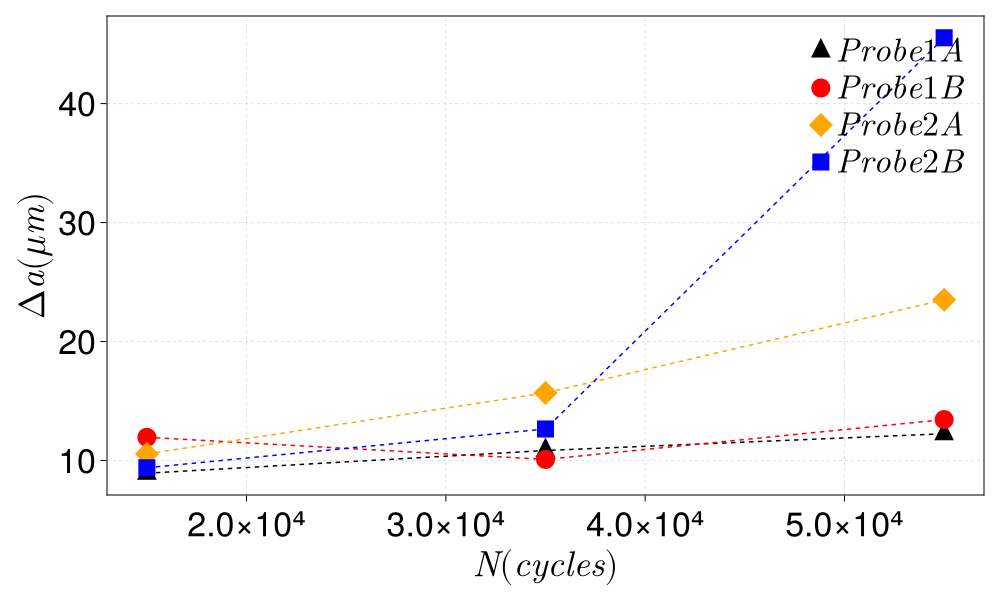

In [41]:
fig

### Plots

In [42]:
font = 36
fig = Figure(resolution = (1000, 600))

axf = Axis(fig[1, 1],
    xlabel = L"log(\Delta G~(\mathrm{J/m^2})",
    ylabel = L"log(\frac{da}{dN})~(\mathrm{m/cycle})",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridvisible = true,   # kein vertikales Grid
    ygridvisible = true


)


Axis with 0 plots:


In [43]:
font = 36
fig2 = Figure(resolution = (1000, 600))

axf2 = Axis(fig2[1, 1],
    xlabel = L"log(\Delta G~(\mathrm{J/m^2})",
    ylabel = L"log(\frac{da}{dN})~(\mu\mathrm{m/cycle})",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridvisible = false,   # kein vertikales Grid
    ygridvisible = false 

)

Axis with 0 plots:


In [44]:

Makie.scatter!(axf2, df_Probe1A."GI", df_Probe1A."dadNMitte";
                        marker = :utriangle,
                        markersize = 15,
                        color = :black)



Scatter{Tuple{Vector{Point{2, Float32}}}}

In [45]:
Makie.scatter!(axf2, df_Probe1B."GI", df_Probe1B."dadNMitte";
                        marker = :utriangle,
                        markersize = 15,
                        color = :red)

Scatter{Tuple{Vector{Point{2, Float32}}}}

In [46]:
Makie.scatter!(axf2, df_Probe2A."GI", df_Probe2A."dadNMitte";
                        marker = :utriangle,
                        markersize = 15,
                        color = :orange)

Scatter{Tuple{Vector{Point{2, Float32}}}}

In [47]:
Makie.scatter!(axf2, df_Probe2B."GI", df_Probe2B."dadNMitte";
                        marker = :utriangle,
                        markersize = 15,
                        color = :blue)

Scatter{Tuple{Vector{Point{2, Float32}}}}

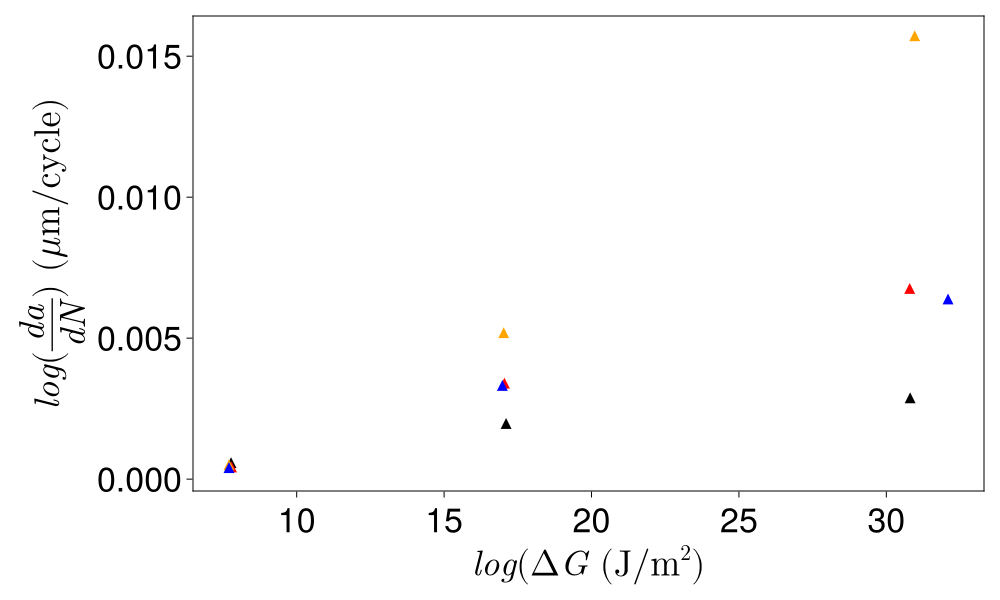

In [48]:
fig2

In [49]:
marksi=20

20

In [50]:
Makie.scatter!(axf, log10.(df_Probe1A."GI"), log10.(df_Probe1A."dadNMitte");
                        marker = :utriangle,
                        markersize = marksi,
                        color = :black, label = "Si-Parylene")

Scatter{Tuple{Vector{Point{2, Float32}}}}

In [51]:
Makie.scatter!(axf, log10.(df_Probe1B."GI"), log10.(df_Probe1B."dadNMitte");
                        marker = :utriangle,
                        markersize = marksi,
                        color = :black)

Scatter{Tuple{Vector{Point{2, Float32}}}}

In [52]:
Makie.scatter!(axf, log10.(df_Probe2A."GI"), log10.(df_Probe2A."dadNMitte");
                        marker = :utriangle,
                        markersize = marksi,
                        color = :black)

Scatter{Tuple{Vector{Point{2, Float32}}}}

In [53]:
Makie.scatter!(axf, log10.(df_Probe2B."GI"), log10.(df_Probe2B."dadNMitte");
                        marker = :utriangle,
                        markersize = marksi,
                        color = :black)



Scatter{Tuple{Vector{Point{2, Float32}}}}

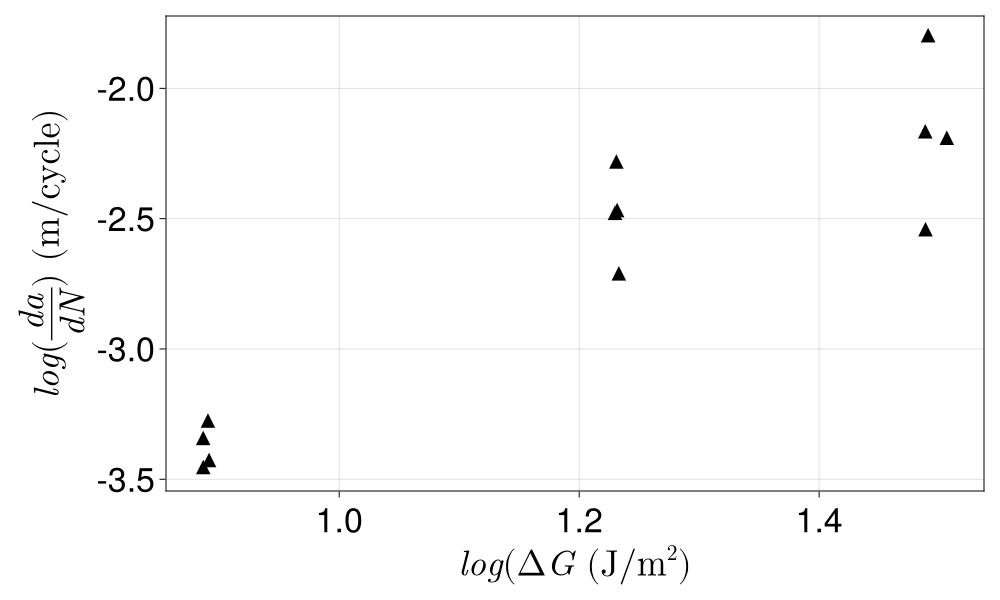

In [54]:
fig

In [55]:
df_Probe1A."GI"

3-element Vector{Float64}:
  7.77300361873382
 17.102107818057675
 30.807079674319315

In [56]:
using CairoMakie
using Statistics

In [57]:

set_theme!(
    fonts = (
        regular = "Times New Roman",
        bold = "Times New Roman",
        italic = "Times New Roman"
    )
)

In [58]:
figPowerLaw = Figure(resolution = (1000, 600));

font=45
axLaw = Axis(figPowerLaw[1,1],
    xlabel = L"log(\Delta G~(\mathrm{J/m^2}))",
    ylabel = L"log(\frac{da}{dN})~(\mu\mathrm{m/cycle})",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false,
    limits = (0.7,1.7,-3.6,-1.5)
    )

Axis with 0 plots:


In [59]:
xx=log10.(df_Probe1A."GI")

3-element Vector{Float64}:
 0.890588869892
 1.2330496400609878
 1.4886505317658436

In [60]:
transpose(xx)

1×3 transpose(::Vector{Float64}) with eltype Float64:
 0.890589  1.23305  1.48865

In [61]:
log10.(df_Probe1A."dadNMitte")

3-element Vector{Float64}:
 -3.283996656365201
 -2.7189666327522723
 -2.5497508916806386

In [62]:
xy=[(df_Probe1A."GI")[1],(df_Probe1B."GI")[1],(df_Probe2A."GI")[1],(df_Probe2B."GI")[1],
(df_Probe1A."GI")[2],(df_Probe1B."GI")[2],(df_Probe2A."GI")[2],(df_Probe2B."GI")[2],
(df_Probe1A."GI")[3],(df_Probe1B."GI")[3],(df_Probe2A."GI")[3],(df_Probe2B."GI")[3]]

12-element Vector{Float64}:
  7.77300361873382
  7.7897494560036895
  7.702408422400052
  7.7031745718176285
 17.102107818057675
 17.045996877177494
 17.021197845270624
 16.976108696349044
 30.807079674319315
 30.792489344612626
 30.962223513533747
 32.09311996909903

In [63]:
x=[log10.(df_Probe1A."GI")[1],log10.(df_Probe1B."GI")[1],log10.(df_Probe2A."GI")[1],log10.(df_Probe2B."GI")[1],
log10.(df_Probe1A."GI")[2],log10.(df_Probe1B."GI")[2],log10.(df_Probe2A."GI")[2],log10.(df_Probe2B."GI")[2],
log10.(df_Probe1A."GI")[3],log10.(df_Probe1B."GI")[3],log10.(df_Probe2A."GI")[3],log10.(df_Probe2B."GI")[3]]

12-element Vector{Float64}:
 0.890588869892
 0.8915234895564034
 0.8866265434858618
 0.8866697400938404
 1.2330496400609878
 1.2316224045439428
 1.2309901197489186
 1.2298381473108861
 1.4886505317658436
 1.4884447998134882
 1.4908321414483063
 1.5064119395790834

In [68]:
yy=[(df_Probe1A."dadNMitte")[1],(df_Probe1B."dadNMitte")[1],(df_Probe2A."dadNMitte")[1],(df_Probe2B."dadNMitte")[1],
(df_Probe1A."dadNMitte")[2],(df_Probe1B."dadNMitte")[2],(df_Probe2A."dadNMitte")[2],(df_Probe2B."dadNMitte")[2],
(df_Probe1A."dadNMitte")[3],(df_Probe1B."dadNMitte")[3],(df_Probe2A."dadNMitte")[3],(df_Probe2B."dadNMitte")[3]]

12-element Vector{Float64}:
 0.00052
 0.0003670000000000002
 0.0004460000000000001
 0.00034499999999999993
 0.0019100000000000002
 0.0033399999999999997
 0.005129999999999999
 0.003259999999999998
 0.0028200000000000005
 0.006699999999999996
 0.015660000000000004
 0.006326000000000008

In [64]:
y=[log10.(df_Probe1A."dadNMitte")[1],log10.(df_Probe1B."dadNMitte")[1],log10.(df_Probe2A."dadNMitte")[1],log10.(df_Probe2B."dadNMitte")[1],
log10.(df_Probe1A."dadNMitte")[2],log10.(df_Probe1B."dadNMitte")[2],log10.(df_Probe2A."dadNMitte")[2],log10.(df_Probe2B."dadNMitte")[2],
log10.(df_Probe1A."dadNMitte")[3],log10.(df_Probe1B."dadNMitte")[3],log10.(df_Probe2A."dadNMitte")[3],log10.(df_Probe2B."dadNMitte")[3]]

12-element Vector{Float64}:
 -3.283996656365201
 -3.4353339357479102
 -3.350665141287858
 -3.462180904926726
 -2.7189666327522723
 -2.4762535331884354
 -2.2898826348881838
 -2.486782399932061
 -2.5497508916806386
 -2.173925197299174
 -1.8052082422780753
 -2.1988708124202954

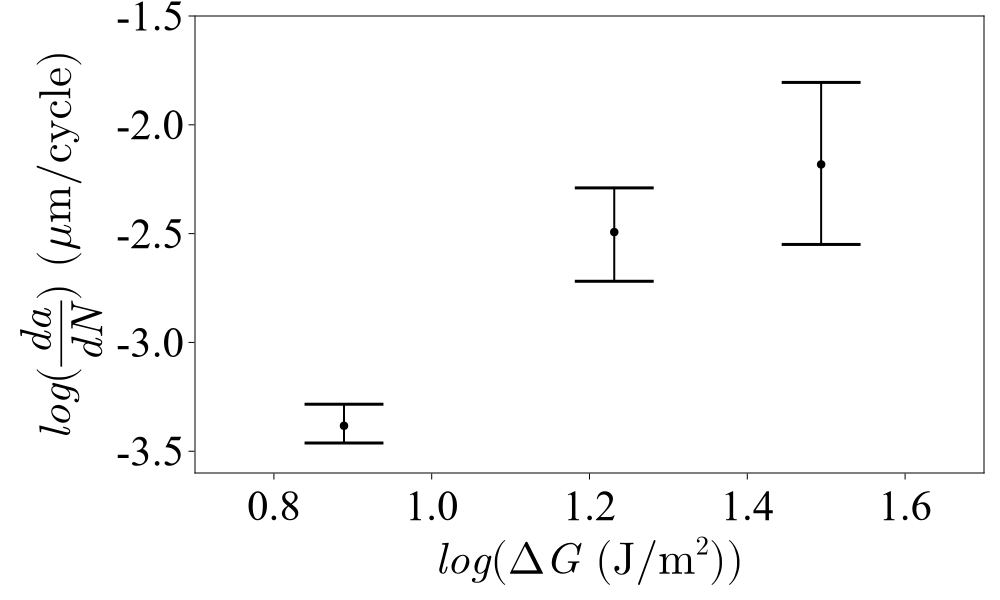

In [65]:
using Makie
using Statistics

#x = [0.88,0.89,0.90,0.91,
 #    1.22,1.23,1.23,1.23,
  #   1.47,1.48,1.48,1.49]

#y = [-3.45,-3.40,-3.35,-3.25,
 #    -2.70,-2.55,-2.45,-2.25,
  #   -2.90,-2.50,-2.45,-2.15]

groups = vcat(fill(1,4), fill(2,4), fill(3,4))


width = 0.05

for g in unique(groups)

    idx = findall(groups .== g)

    xmean = mean(x[idx])
    ymean = mean(y[idx])
    ymin  = minimum(y[idx])
    ymax  = maximum(y[idx])

    # vertical line
    Makie.lines!(axLaw, [xmean, xmean], [ymin, ymax],
        color = :black, linewidth = 2)

    # min horizontal cap
    Makie.lines!(axLaw, [xmean-width, xmean+width], [ymin, ymin],
        color = :black, linewidth = 3)

    # max horizontal cap
    Makie.lines!(axLaw, [xmean-width, xmean+width], [ymax, ymax],
        color = :black, linewidth = 3)

    # mean point
    Makie.scatter!(axLaw, [xmean], [ymean],
        color = :black,
        markersize = 12
    )
end

figPowerLaw

In [66]:
save("PowerLaw.pdf", figPowerLaw)

CairoMakie.Screen{PDF}
